In [173]:
import pandas as pd
import os
from io import StringIO
from pandas import json_normalize
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import hmean

In [174]:
folder = os.path.join("output","runs","Parameter_ablation", "LinkAttack")

files = ['Citeseer_GCN_edge.json', 'Cora_GCN_edge.json', 'pubmed_GCN_edge.json', 'AmazonComputers_GCN_edge.json']
files

['Citeseer_GCN_edge.json',
 'Cora_GCN_edge.json',
 'pubmed_GCN_edge.json',
 'AmazonComputers_GCN_edge.json']

In [175]:
column_list = ['unlearner', 'dataset', 'architecture', 'optimizer.parameters.lr','lr',
       'RunTime', 'PeakRSS_MB', 'CudaPeak_MB', 'AUS', 'UMIA',
       'sklearn.metrics.accuracy_score.test.unlearned.on_graph:True', 'sklearn.metrics.accuracy_score.forget.unlearned.on_graph:True',
       'sklearn.metrics.accuracy_score.train.unlearned.on_graph:True',
       'sklearn.metrics.accuracy_score.test.unlearned.on_graph:False',
       'sklearn.metrics.accuracy_score.test.original.on_graph:False',
       'f1_macro.test.unlearned.on_graph:True',
       'f1_macro.test.original.on_graph:True',
       'f1_macro.forget.unlearned.on_graph:True',
       'f1_macro.forget.original.on_graph:True',
       'Link Stealing Attack unlearned 0 exist/non_exist',
       'Link Stealing Attack 0 unlearned forget/non_exist', 'LinkTeller unlearn with sampler bfs+:',
       'LinkTeller original with sampler bfs+:']


In [176]:
total_df = pd.DataFrame()

for file in files:
    architecture = file.split("_")[1]
    if architecture == "SGC" and "CGU" in file:
        architecture = "SGC_CGU"
        
    file = os.path.join(folder,file)
    with open(file, "r") as f:
        text = f.read().strip()

    if not text.startswith("["):
        text = "[" + text
    if text.endswith(","):
        text = text[:-1]
    if not text.endswith("]"):
        text = text + "]"

    df = pd.read_json(StringIO(text))

    df_expanded = json_normalize(df['parameters'])
    df = pd.concat([df.drop(columns='parameters'), df_expanded], axis=1)

    df['architecture'] = architecture

    cols = list(df.columns)

    #cols.insert(2, cols.pop(cols.index('optimizer.parameters.lr')))

    cols.insert(2, cols.pop(cols.index('architecture')))

    df = df[cols]
    
    total_df = pd.concat([total_df,df])

In [177]:
total_df = total_df[column_list]

In [178]:
linkteller_unlearn = total_df["LinkTeller unlearn with sampler bfs+:"].apply(pd.Series)
linkteller_unlearn = linkteller_unlearn.rename(columns=lambda x: f"LinkTeller_unlearn_{x}")

linkteller_original = total_df["LinkTeller original with sampler bfs+:"].apply(pd.Series)
linkteller_original = linkteller_original.rename(columns=lambda x: f"LinkTeller_original_{x}")

total_df = pd.concat([total_df.drop(columns=[
    "LinkTeller unlearn with sampler bfs+:",
    "LinkTeller original with sampler bfs+:"
]), linkteller_unlearn, linkteller_original], axis=1)

total_df.drop(columns=["LinkTeller_unlearn_0", "LinkTeller_original_0"], inplace=True)


In [179]:
total_df

,unlearner,dataset,architecture,optimizer.parameters.lr,lr,RunTime,PeakRSS_MB,CudaPeak_MB,AUS,UMIA,...,f1_macro.test.unlearned.on_graph:True,f1_macro.test.original.on_graph:True,f1_macro.forget.unlearned.on_graph:True,f1_macro.forget.original.on_graph:True,Link Stealing Attack unlearned 0 exist/non_exist,Link Stealing Attack 0 unlearned forget/non_exist,LinkTeller_unlearn_auc,LinkTeller_unlearn_ap,LinkTeller_original_auc,LinkTeller_original_ap
0,Identity,Citeseer,GCN,NaN,NaN,0.000143,3305.882812,NaN,0.958060,0.534897,...,0.634660,0.634660,0.687313,0.687313,0.901390,0.884562,0.760905,0.913856,0.760905,0.913856
1,GoldModelGraph,Citeseer,GCN,NaN,NaN,0.779713,3379.429688,NaN,0.965780,0.564916,...,0.628258,0.628258,0.697258,0.697258,0.906347,0.893295,0.760938,0.919998,0.760938,0.919998
2,Finetuning,Citeseer,GCN,0.001,NaN,0.379789,3412.875000,NaN,0.960037,0.529081,...,0.646709,0.646709,0.695493,0.695493,0.907022,0.893683,0.760959,0.913798,0.760959,0.913798
3,Finetuning,Citeseer,GCN,0.100,NaN,0.386404,3542.109375,NaN,0.993277,0.498311,...,0.689069,0.689069,0.694386,0.694386,0.935118,0.938756,0.764326,0.915715,0.764326,0.915715
4,Finetuning,Citeseer,GCN,1.000,NaN,0.541377,3543.972656,NaN,0.988237,0.495497,...,0.651192,0.651192,0.669591,0.669591,0.879371,0.878082,0.764026,0.916311,0.764026,0.916311
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36,Cascade,Computers,GCN,NaN,NaN,840.595609,6083.300781,2676.715332,0.998205,0.500227,...,0.004060,0.004060,0.004625,0.004625,0.738188,0.737672,0.834042,0.839020,0.833282,0.838717
37,Cascade,Computers,GCN,NaN,NaN,803.859904,6094.101562,2677.310059,0.998205,0.504543,...,0.004060,0.004060,0.004625,0.004625,0.500000,0.500000,0.833388,0.837821,0.833564,0.837847
38,IDEA,Computers,GCN,NaN,NaN,12.831788,3080.160156,1670.435059,0.999315,-1.000000,...,0.006404,0.006404,0.006392,0.006392,NaN,NaN,NaN,NaN,NaN,NaN
39,CGU_edge,Computers,GCN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.176400,NaN,0.172460,NaN,NaN,NaN,NaN,0.829996,0.836343


In [180]:
metric_cols = [c for c in df.columns if c not in ["unlearner","dataset","architecture","lr","RunTime"]]

gold_baseline = total_df.loc[total_df.unlearner == 'GoldModelGraph']

for i, row in df.iterrows():
    if row["unlearner"] in ["Identity", "GoldModelGraph"]:
        continue  

    arch = row["architecture"]
    if arch in gold_baseline['architecture']:
        for col in metric_cols:
            df.at[i, col] = row[col] - gold_baseline.loc[arch, col]

In [181]:
df

,unlearner,dataset,architecture,RunTime,PeakRSS_MB,CudaPeak_MB,AIN,AUS,UMIA,sklearn.metrics.accuracy_score.test.unlearned.on_graph:True,...,compare_retrain,delta,eps,train_mode,y_binary,lam,num_steps_optimizer,cg_approx,transductive_edge,damping
0,Identity,Computers,GCN,0.000460,4398.968750,2445.258789,0.003322,0.997219,0.498501,0.491458,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,GoldModelGraph,Computers,GCN,0.366018,4848.496094,2615.873535,1.000000,0.994762,0.496683,0.448201,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Finetuning,Computers,GCN,48.950011,4909.562500,2665.550293,0.000555,0.996416,0.498682,0.651763,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Finetuning,Computers,GCN,40.678860,5254.566406,2665.925781,1.000000,0.989480,0.499909,0.167212,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Finetuning,Computers,GCN,32.457010,5302.058594,2665.415039,1.000000,0.989480,0.507269,0.167212,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,SuccessiveRandomLabels,Computers,GCN,765.343797,5310.300781,2665.712891,1.000000,0.997951,0.500182,0.597601,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,SuccessiveRandomLabels,Computers,GCN,720.049850,5372.929688,2666.010742,1.000000,0.993785,0.496411,0.053072,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,SuccessiveRandomLabels,Computers,GCN,719.454954,5376.144531,2666.308594,1.000000,0.993785,0.496093,0.053072,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Finetuning,Computers,GCN,39.162283,5416.671875,2666.606445,1.000000,0.999080,0.499818,0.633224,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Finetuning,Computers,GCN,31.011638,5438.671875,2666.904297,1.000000,0.989480,0.510495,0.167212,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [182]:
def harmonic_mean(row, metrics):
    values = row[metrics].values
    values = values[values > 0]
    if len(values) == 0:
        return np.nan
    return len(values) / np.sum(1.0 / values)

In [183]:
column_list = ['unlearner', 'dataset', 'architecture', 'optimizer.parameters.lr','lr',
       'RunTime', 'AUS', 'UMIA',
       'sklearn.metrics.accuracy_score.test.unlearned.on_graph:True', 'sklearn.metrics.accuracy_score.forget.unlearned.on_graph:True',
       'sklearn.metrics.accuracy_score.train.unlearned.on_graph:True',
       'sklearn.metrics.accuracy_score.test.unlearned.on_graph:False',
       'sklearn.metrics.accuracy_score.test.original.on_graph:False',
       'Link Stealing Attack unlearned 0 exist/non_exist',
       'Link Stealing Attack 0 unlearned forget/non_exist', 'LinkTeller_unlearn_auc',
       'LinkTeller_unlearn_ap', 'LinkTeller_original_auc', 'LinkTeller_original_ap']

total_df = total_df[column_list]
total_df.reset_index(drop=True, inplace=True)

In [184]:
metric_cols = [c for c in column_list if c not in ["unlearner","dataset","architecture","lr","RunTime", 'optimizer.parameters.lr',  'Link Stealing Attack unlearned 0 exist/non_exist',
 'Link Stealing Attack 0 unlearned forget/non_exist',
 'LinkTeller_unlearn_auc',
 'LinkTeller_unlearn_ap',
 'LinkTeller_original_auc',
 'LinkTeller_original_ap']]

In [185]:
metric_cols

['AUS',
 'UMIA',
 'sklearn.metrics.accuracy_score.test.unlearned.on_graph:True',
 'sklearn.metrics.accuracy_score.forget.unlearned.on_graph:True',
 'sklearn.metrics.accuracy_score.train.unlearned.on_graph:True',
 'sklearn.metrics.accuracy_score.test.unlearned.on_graph:False',
 'sklearn.metrics.accuracy_score.test.original.on_graph:False']

In [186]:
total_df[metric_cols] = total_df[metric_cols].clip(lower=0)

/tmp/ipykernel_3167015/2383361326.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  total_df[metric_cols] = total_df[metric_cols].clip(lower=0)


In [187]:
total_df["harmonic_mean"] = total_df[metric_cols].apply(
    lambda row: hmean(row.dropna()) if row.dropna().size > 0 else np.nan,
    axis=1
)

/tmp/ipykernel_3167015/2817058301.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  total_df["harmonic_mean"] = total_df[metric_cols].apply(


In [188]:
total_df

,unlearner,dataset,architecture,optimizer.parameters.lr,lr,RunTime,AUS,UMIA,sklearn.metrics.accuracy_score.test.unlearned.on_graph:True,sklearn.metrics.accuracy_score.forget.unlearned.on_graph:True,sklearn.metrics.accuracy_score.train.unlearned.on_graph:True,sklearn.metrics.accuracy_score.test.unlearned.on_graph:False,sklearn.metrics.accuracy_score.test.original.on_graph:False,Link Stealing Attack unlearned 0 exist/non_exist,Link Stealing Attack 0 unlearned forget/non_exist,LinkTeller_unlearn_auc,LinkTeller_unlearn_ap,LinkTeller_original_auc,LinkTeller_original_ap,harmonic_mean
0,Identity,Citeseer,GCN,NaN,NaN,0.000143,0.958060,0.534897,0.726727,0.772673,0.763257,0.734234,0.734234,0.901390,0.884562,0.760905,0.913856,0.760905,0.913856,0.727829
1,GoldModelGraph,Citeseer,GCN,NaN,NaN,0.779713,0.965780,0.564916,0.726727,0.773270,0.768685,0.726727,0.726727,0.906347,0.893295,0.760938,0.919998,0.760938,0.919998,0.734689
2,Finetuning,Citeseer,GCN,0.001,NaN,0.379789,0.960037,0.529081,0.740240,0.779833,0.770772,0.744745,0.744745,0.907022,0.893683,0.760959,0.913798,0.760959,0.913798,0.733152
3,Finetuning,Citeseer,GCN,0.100,NaN,0.386404,0.993277,0.498311,0.783784,0.783413,0.772860,0.783784,0.783784,0.935118,0.938756,0.764326,0.915715,0.764326,0.915715,0.743771
4,Finetuning,Citeseer,GCN,1.000,NaN,0.541377,0.988237,0.495497,0.756757,0.774463,0.762004,0.762763,0.762763,0.879371,0.878082,0.764026,0.916311,0.764026,0.916311,0.730910
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
162,Cascade,Computers,GCN,NaN,NaN,840.595609,0.998205,0.500227,0.020720,0.023673,0.022826,0.020720,0.020720,0.738188,0.737672,0.834042,0.839020,0.833282,0.838717,0.029935
163,Cascade,Computers,GCN,NaN,NaN,803.859904,0.998205,0.504543,0.020720,0.023673,0.022826,0.020720,0.020720,0.500000,0.500000,0.833388,0.837821,0.833564,0.837847,0.029937
164,IDEA,Computers,GCN,NaN,NaN,12.831788,0.999315,0.000000,0.033079,0.033014,0.031815,0.033079,0.033079,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
165,CGU_edge,Computers,GCN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.487823,NaN,NaN,NaN,NaN,0.829996,0.836343,0.487823


In [189]:
df_to_plot = total_df[['unlearner','dataset','optimizer.parameters.lr','UMIA','sklearn.metrics.accuracy_score.test.unlearned.on_graph:True']]
df_to_plot.columns

Index(['unlearner', 'dataset', 'optimizer.parameters.lr', 'UMIA',
       'sklearn.metrics.accuracy_score.test.unlearned.on_graph:True'],
      dtype='object')

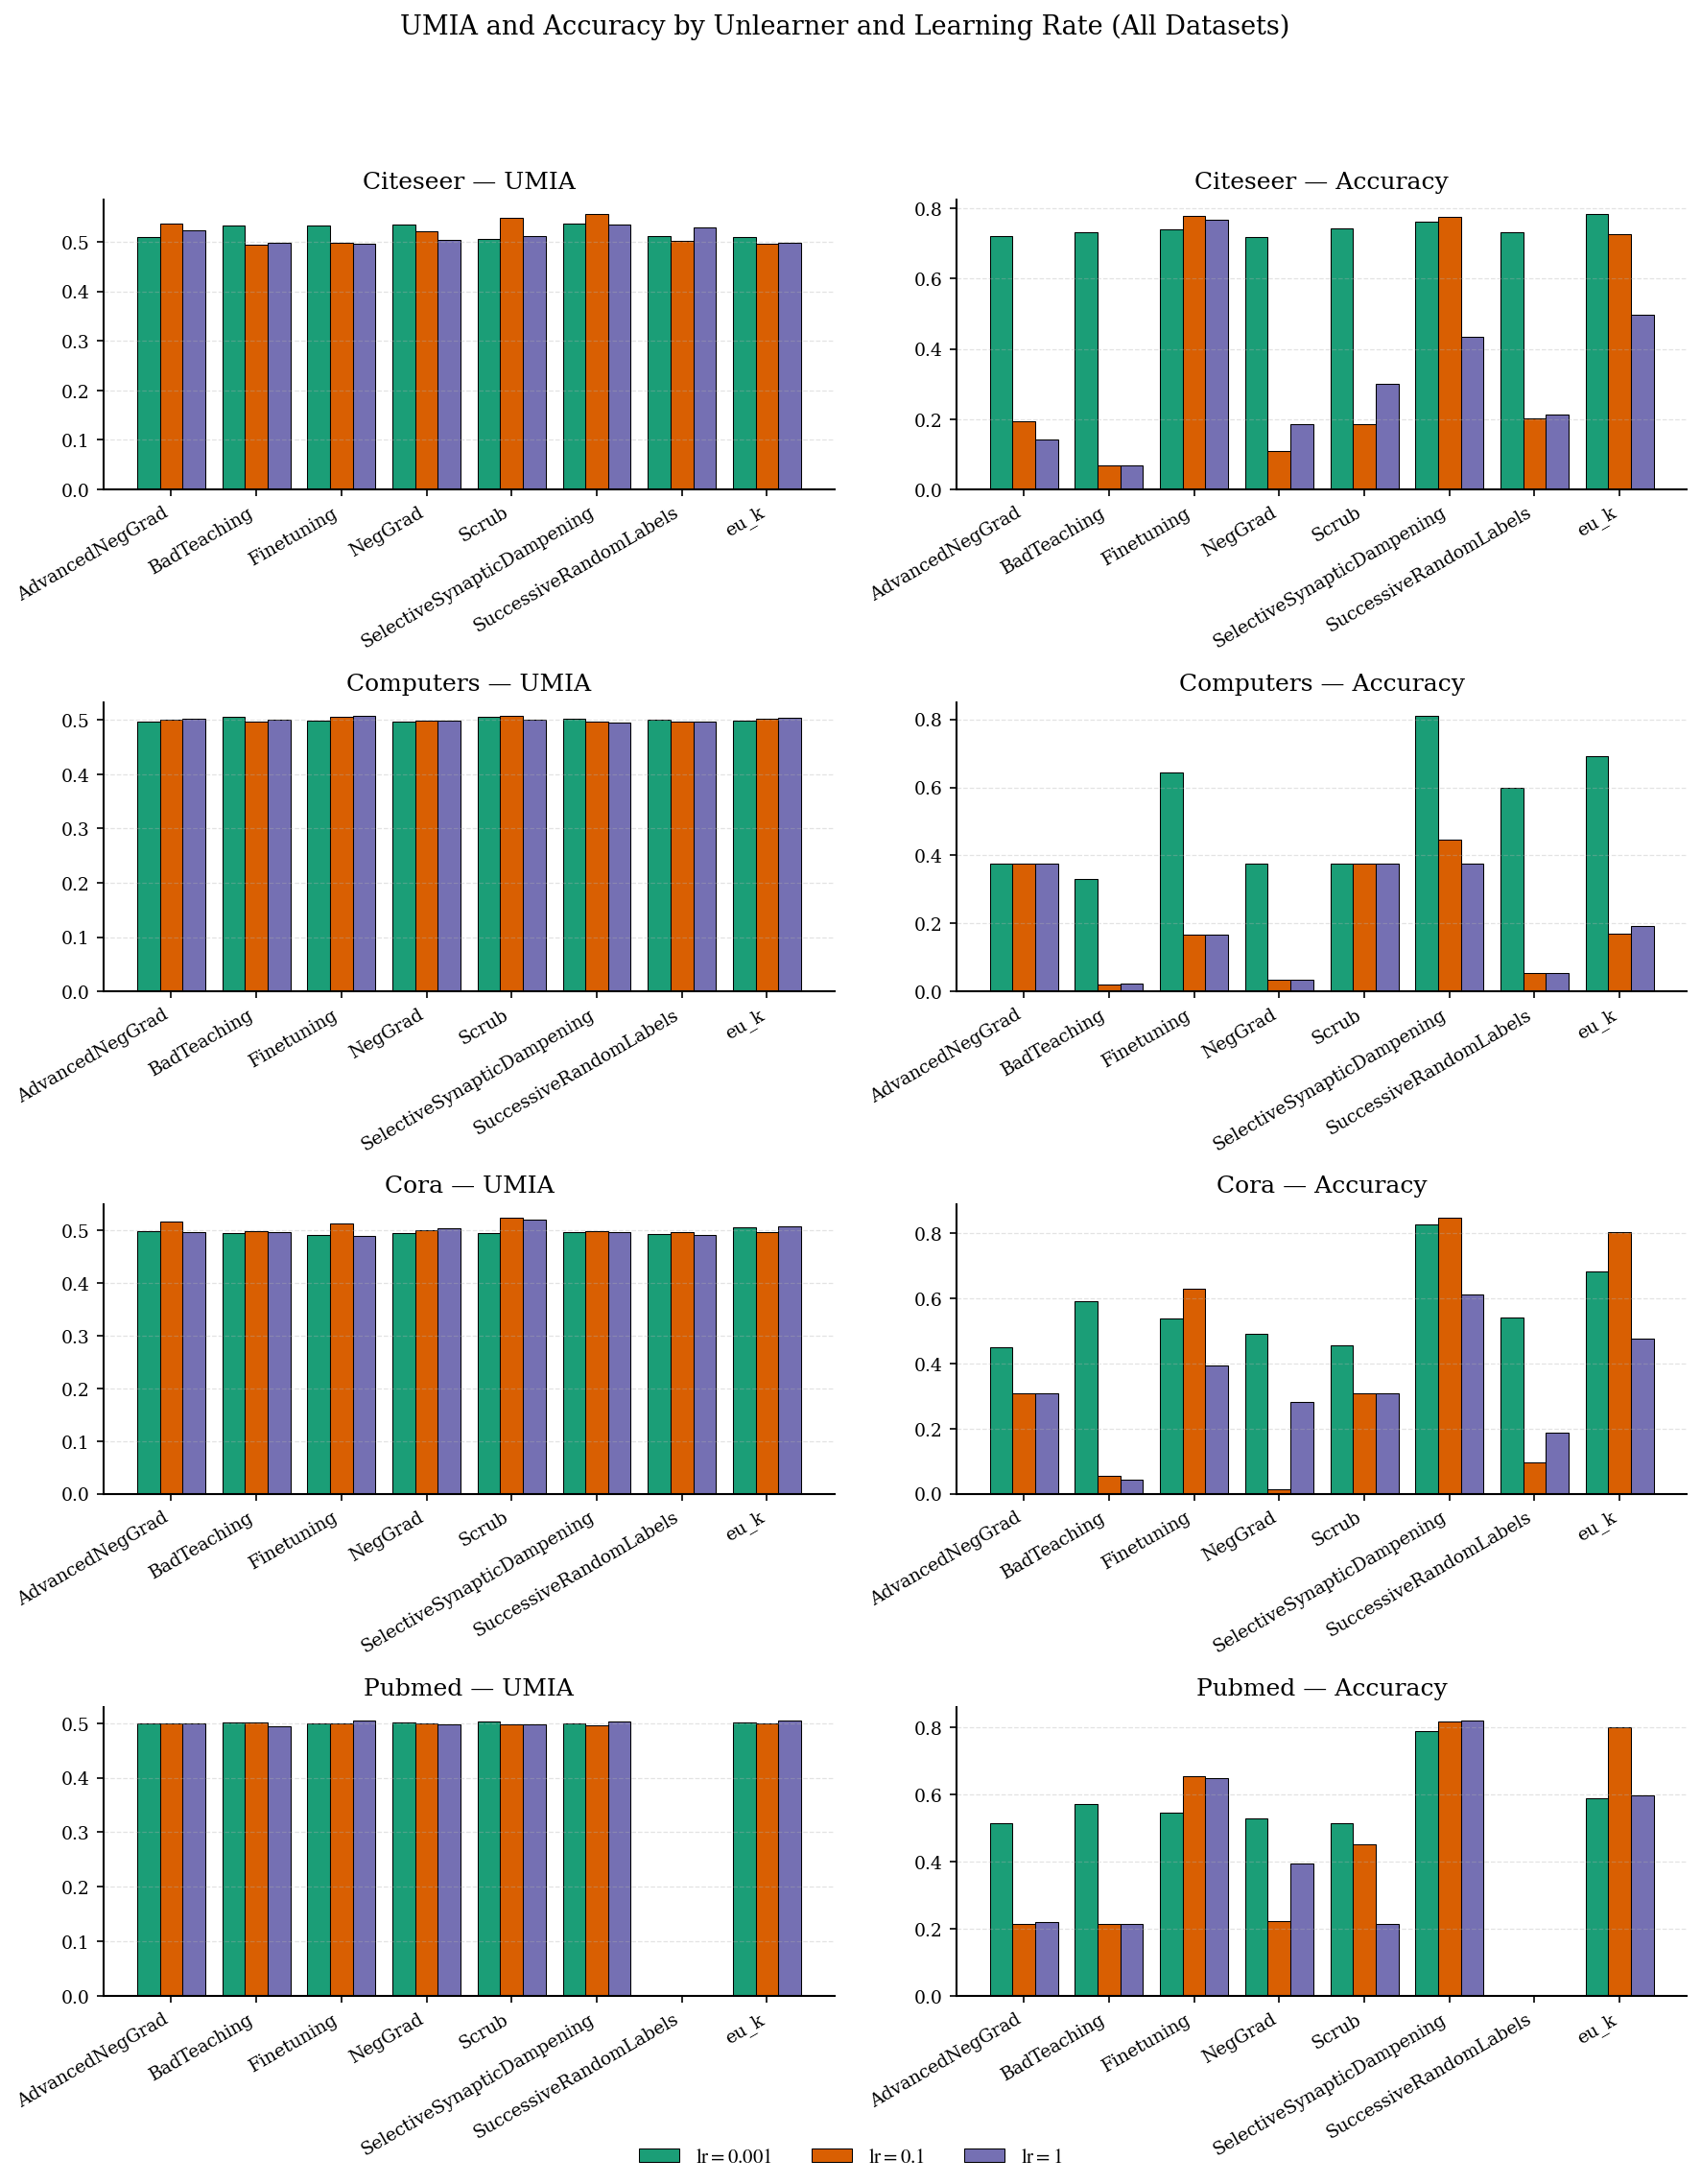

In [192]:
import os, re, math
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd

ACC_COL = "sklearn.metrics.accuracy_score.test.unlearned.on_graph:True"

# ---------- Academic style ----------
mpl.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 1.0,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 10,
    "font.family": "DejaVu Serif",  # swap to "Times New Roman" if you prefer
    "mathtext.fontset": "stix",
    "grid.linewidth": 0.6,
    "grid.alpha": 0.35,
})

# Muted, research-friendly colors (ColorBrewer-inspired)
PALETTE = ["#1b9e77", "#d95f02", "#7570b3", "#e7298a", "#66a61e", "#e6ab02"]

# ---------- Prep data ----------
dfp = (
    df_to_plot
    .dropna(subset=["optimizer.parameters.lr"])
    .rename(columns={"optimizer.parameters.lr": "lr", ACC_COL: "Accuracy"})
)

datasets = sorted(dfp["dataset"].unique())
n_datasets = len(datasets)

# Global LR color mapping (consistent across datasets)
global_lrs = sorted(dfp["lr"].unique())
LR_COLOR = {lr: PALETTE[i % len(PALETTE)] for i, lr in enumerate(global_lrs)}

# ---------- Plot ----------
ncols = 2
nrows = n_datasets
fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 3.8*nrows), squeeze=False)

def plot_metric(ax, agg, unlearners, lrs, metric, title):
    x = np.arange(len(unlearners))
    width = 0.8 / max(1, len(lrs))
    offsets = (np.arange(len(lrs)) - (len(lrs)-1)/2) * width

    for i, lr in enumerate(lrs):
        vals = agg.xs(lr, level="lr")[metric].reindex(unlearners).values
        ax.bar(x + offsets[i], vals, width, color=LR_COLOR[lr], edgecolor="black", linewidth=0.5,
               label=rf"$\mathrm{{lr}}={lr:g}$" if metric == "UMIA" else None)

    ax.set_xticks(x)
    ax.set_xticklabels(unlearners, rotation=30, ha="right")
    ax.set_title(title)
    ax.grid(axis="y", linestyle="--")

    # subtle y=0 baseline for reference
    ax.axhline(0, color="black", linewidth=0.8)

for row, ds in enumerate(datasets):
    dsub = dfp[dfp["dataset"] == ds]
    agg = (
        dsub.groupby(["unlearner", "lr"], dropna=False)[["UMIA", "Accuracy"]]
            .mean().sort_index()
    )
    unlearners = sorted(agg.index.get_level_values("unlearner").unique())
    lrs = sorted(agg.index.get_level_values("lr").unique())

    plot_metric(axes[row, 0], agg, unlearners, lrs, "UMIA", f"{ds} — UMIA")
    plot_metric(axes[row, 1], agg, unlearners, lrs, "Accuracy", f"{ds} — Accuracy")

# Shared legend (single row, centered)
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=min(len(global_lrs), 6), frameon=False)

fig.suptitle("UMIA and Accuracy by Unlearner and Learning Rate (All Datasets)", fontsize=13, y=0.99)
fig.tight_layout(rect=[0, 0, 1, 0.95])

# Optional: save as vector for papers
os.makedirs("figures", exist_ok=True)
fig.savefig(os.path.join("figures", "all_datasets_grid.pdf"))
plt.show()
